# Modelo de Regresion Lineal
## Prediccion del Indice de Productividad del Suelo (IPS)
### Dataset: `suelos_regresion_lineal.csv`
---

## 1. Carga de Datos

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.preprocessing import StandardScaler
from scipy import stats
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12,6)

BASE = r'C:\Users\ivanq\Desktop\Talento tech\trabajo final'
df = pd.read_csv('suelos_regresion_lineal.csv')
print(f'Dimensiones: {df.shape}')
df.head(3)

Dimensiones: (42510, 351)


,pH,MO,fosforo,azufre,calcio,magnesio,potasio,CIC,CE,anios_est,...,riego_Goteo,riego_Goteo - Gravedad,riego_Gravedad,riego_Manguera,riego_No Tiene,riego_Por Inundaciã³N,riego_Superficial,riego_Superficial - Goteo,riego_Superficial - Inundaciã³N,riego_Superficial-Aspersiã³N
0,5.64,3.889,6.482,8.384,1.541,0.380,0.118,2.094,0.133,0.5,...,False,False,False,False,False,False,False,False,False,False
1,4.24,2.287,520.100,90.300,2.932,0.925,2.131,8.054,2.749,3.0,...,False,False,False,False,True,False,False,False,False,False
2,5.22,2.518,58.110,2.686,3.818,1.110,0.045,5.985,0.328,0.5,...,False,False,False,False,True,False,False,False,False,False


## 2. Analisis Exploratorio (EDA)

In [5]:
feats = ['pH','MO','fosforo','azufre','calcio','magnesio','potasio','CIC','CE','anios_est']
df[feats].describe()

,pH,MO,fosforo,azufre,calcio,magnesio,potasio,CIC,CE,anios_est
count,42510.000000,42510.000000,42510.000000,42510.000000,42510.000000,42510.000000,42510.000000,42510.000000,42510.000000,42510.000000
mean,5.742537,5.078205,35.561061,13.608576,7.526079,2.031682,0.387775,11.156042,0.499725,2.572242
std,1.033452,5.159060,85.980014,48.712291,9.080770,2.549252,0.700780,10.339368,1.261055,4.135370
min,3.190000,0.011000,0.088000,-1.010000,0.028000,0.006000,0.045000,0.196000,0.004000,0.500000
25%,4.970000,1.888000,4.140000,3.738250,1.778000,0.472000,0.124000,4.469000,0.166000,0.500000
50%,5.510000,3.197000,10.320000,6.138000,4.642000,1.113000,0.238000,7.828000,0.257000,0.500000
75%,6.320000,6.207750,32.387500,11.230000,9.890750,2.437000,0.460000,14.300000,0.454000,3.000000
max,10.570000,75.040000,3015.000000,4862.000000,137.100000,30.650000,64.060000,153.300000,45.820000,15.000000


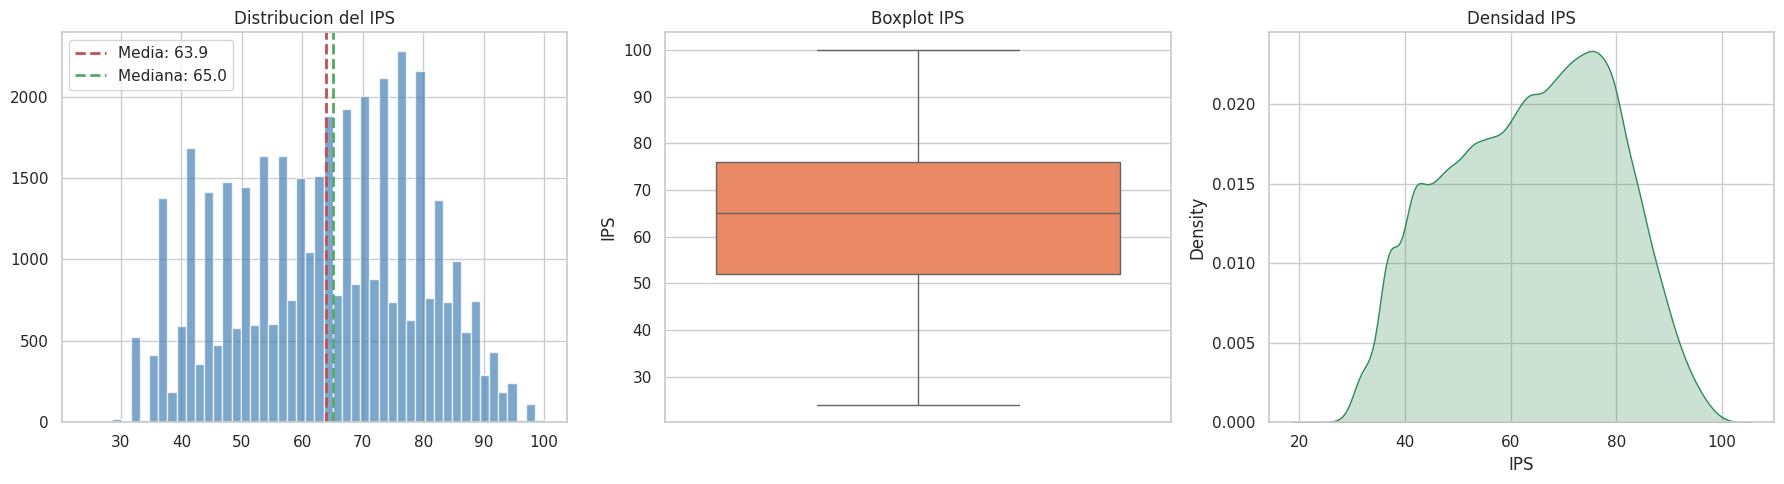

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes[0].hist(df['IPS'], bins=50, color='steelblue', ec='black', alpha=0.7)
axes[0].axvline(df['IPS'].mean(), color='r', ls='--', lw=2, label=f'Media: {df["IPS"].mean():.1f}')
axes[0].axvline(df['IPS'].median(), color='g', ls='--', lw=2, label=f'Mediana: {df["IPS"].median():.1f}')
axes[0].set_title('Distribucion del IPS'); axes[0].legend()
sns.boxplot(y=df['IPS'], ax=axes[1], color='coral'); axes[1].set_title('Boxplot IPS')
sns.kdeplot(df['IPS'], ax=axes[2], fill=True, color='seagreen'); axes[2].set_title('Densidad IPS')
plt.tight_layout(); plt.show()

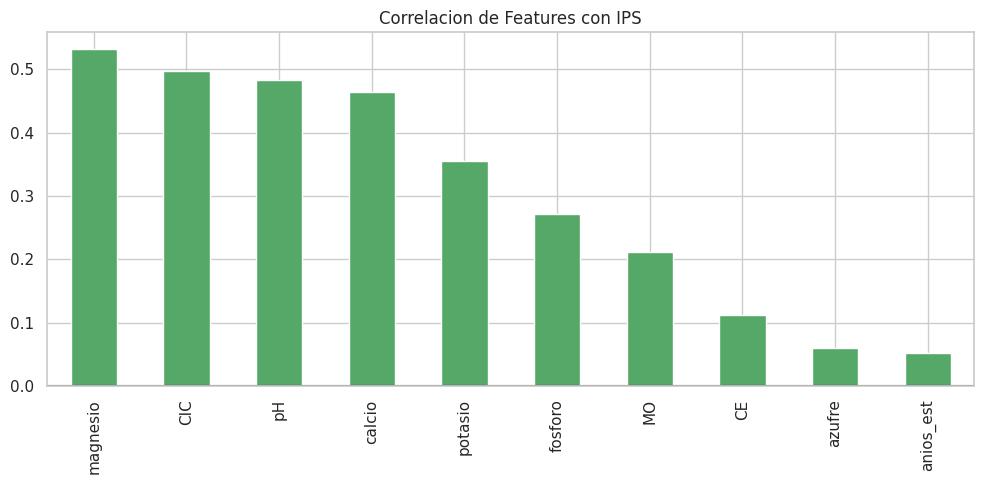

magnesio     0.531450
CIC          0.497071
pH           0.482570
calcio       0.464285
potasio      0.355525
fosforo      0.272035
MO           0.210741
CE           0.112686
azufre       0.059512
anios_est    0.052333


In [7]:
corr = df[feats + ['IPS']].corr()['IPS'].drop('IPS').sort_values(ascending=False)
plt.figure(figsize=(10,5))
colors = ['g' if v>0 else 'r' for v in corr.values]
corr.plot(kind='bar', color=colors)
plt.title('Correlacion de Features con IPS')
plt.axhline(0, color='k'); plt.tight_layout(); plt.show()
print(corr.to_string())

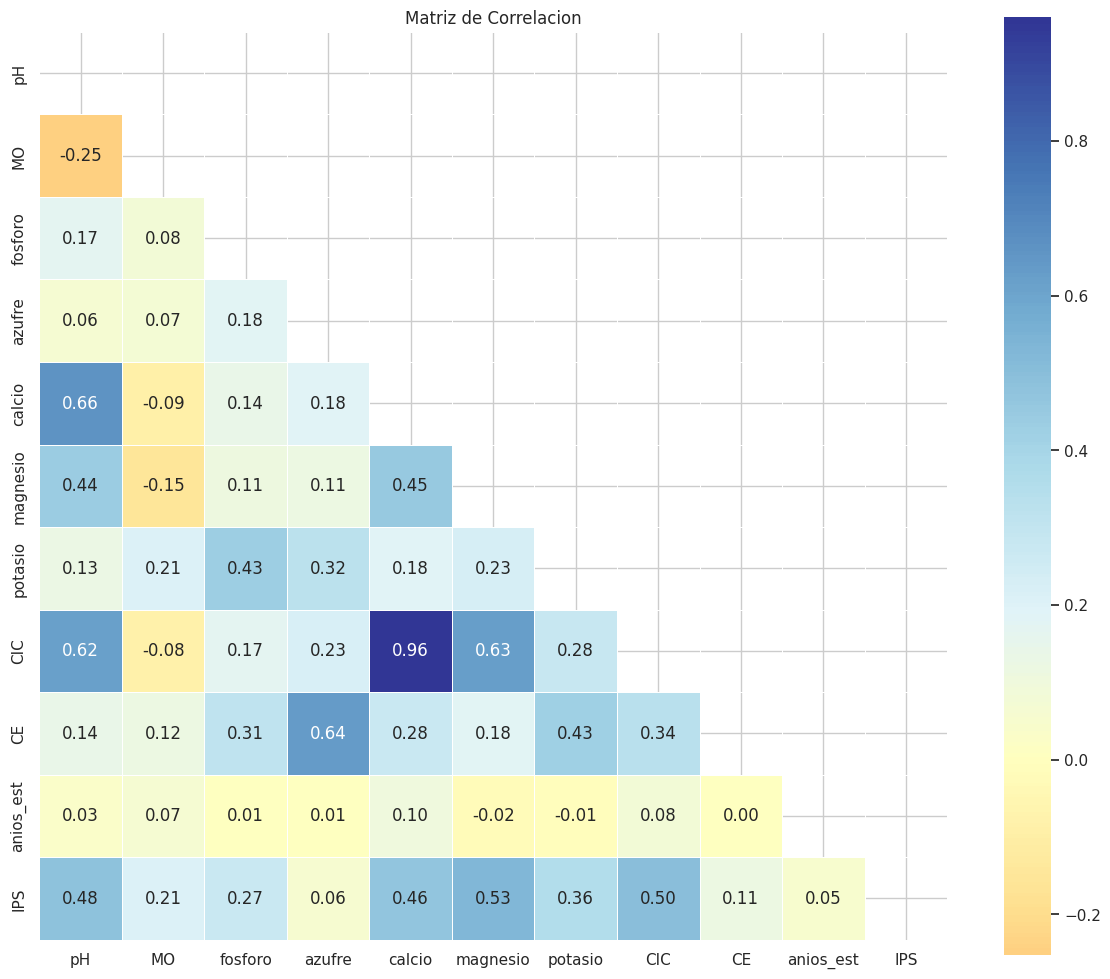

In [8]:
plt.figure(figsize=(12,10))
mask = np.triu(np.ones_like(df[feats+['IPS']].corr(), dtype=bool))
sns.heatmap(df[feats+['IPS']].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdYlBu', center=0, square=True, linewidths=0.5)
plt.title('Matriz de Correlacion'); plt.tight_layout(); plt.show()

## 3. Preparacion de Datos

In [16]:
X = df.drop(columns=['IPS']); y = df['IPS']

categorical_cols_to_onehot = []

for col in X.columns:
    if X[col].dtype == 'bool':
        # Convert explicit boolean columns to int (0 or 1)
        X[col] = X[col].astype(int)
    elif X[col].dtype == 'object':
        temp_col_lower = X[col].astype(str).str.lower() # Convert to string and lower for consistent checks

        if temp_col_lower.isin(['true', 'false', 'nan']).all():
            # If column contains only boolean-like strings or NaNs, map to 0/1
            X[col] = temp_col_lower.map({'true': 1, 'false': 0}).fillna(0).astype(int)
        else:
            # Attempt to convert to numeric. If it creates new NaNs, it's not purely numeric.
            numeric_attempt = pd.to_numeric(X[col], errors='coerce')

            # Check if conversion to numeric succeeded without introducing new NaNs (compared to original NaNs)
            # and if all non-NaNs are now numeric.
            if numeric_attempt.isnull().sum() == X[col].isnull().sum() and all(pd.api.types.is_numeric_dtype(numeric_attempt.dropna()) for _ in [0]):
                # If conversion to numeric worked for all non-NaNs, use it
                X[col] = numeric_attempt
            else:
                # Column contains true categorical strings or mixed types that are not boolean-like/purely numeric
                categorical_cols_to_onehot.append(col)

# One-hot encode the identified categorical columns
if len(categorical_cols_to_onehot) > 0:
    X = pd.get_dummies(X, columns=categorical_cols_to_onehot, drop_first=True)

# Fill any remaining NaNs in numerical columns (all columns should be numerical by now)
for col in X.select_dtypes(include=np.number).columns:
    if X[col].isnull().any():
        X[col] = X[col].fillna(X[col].mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train); X_test_s = scaler.transform(X_test)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (34008, 352), Test: (8502, 352)


## 4. Modelo Base: Regresion Lineal

In [17]:
lr = LinearRegression()
lr.fit(X_train_s, y_train); y_pred = lr.predict(X_test_s)
r2 = r2_score(y_test, y_pred); rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
print(f'R²: {r2:.4f}, RMSE: {rmse:.2f}, MAE: {mae:.2f}')
cv = cross_val_score(lr, X_train_s, y_train, cv=5, scoring='r2')
print(f'CV R²: {cv.mean():.4f} +/- {cv.std():.4f}')

R²: 0.6597, RMSE: 8.94, MAE: 7.06
CV R²: 0.6498 +/- 0.0060


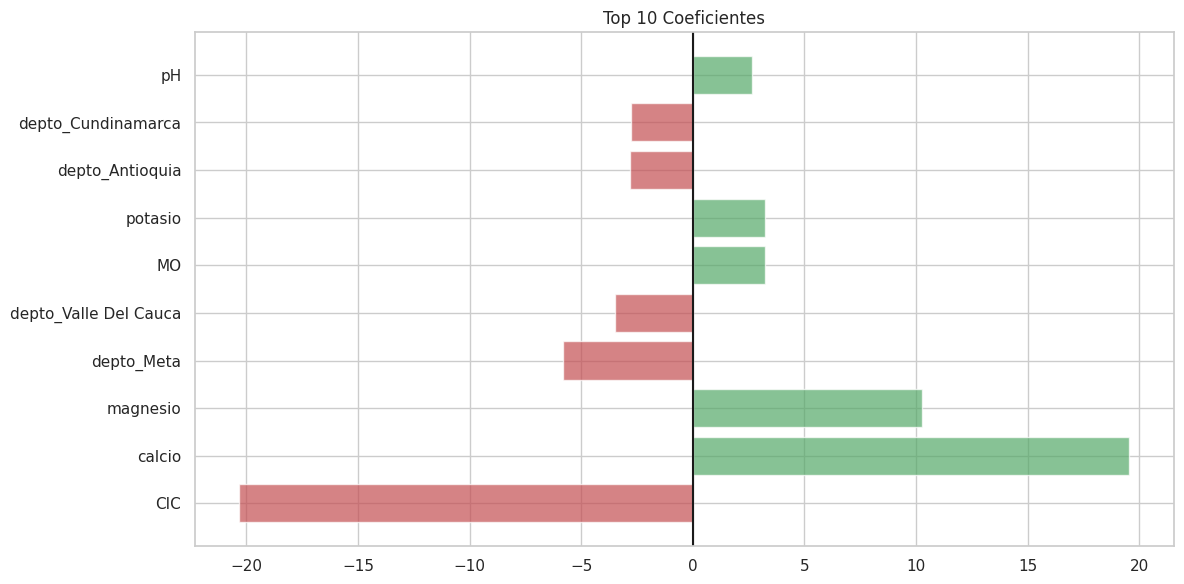

              feature       coef
                  CIC -20.322955
               calcio  19.566412
             magnesio  10.293310
           depto_Meta  -5.811655
depto_Valle Del Cauca  -3.469554
                   MO   3.237019
              potasio   3.236985
      depto_Antioquia  -2.803202
   depto_Cundinamarca  -2.787804
                   pH   2.644703


In [20]:
coef = pd.DataFrame({'feature':X.columns,'coef':lr.coef_}).sort_values('coef', key=abs, ascending=False).head(10)
plt.figure(figsize=(12,6))
colors = ['g' if c>0 else 'r' for c in coef['coef']]
plt.barh(coef['feature'], coef['coef'], color=colors, alpha=0.7)
plt.axvline(0, color='k'); plt.title('Top 10 Coeficientes'); plt.tight_layout(); plt.show()
print(coef[['feature','coef']].to_string(index=False))

## 5. Optimizacion: Ridge y Lasso

In [22]:
params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge = GridSearchCV(Ridge(), params, cv=5, scoring='r2', n_jobs=-1).fit(X_train_s, y_train)
lasso = GridSearchCV(Lasso(max_iter=10000), params, cv=5, scoring='r2', n_jobs=-1).fit(X_train_s, y_train)
print(f'Ridge alpha={ridge.best_params_["alpha"]}, R² val={ridge.best_score_:.4f}')
print(f'Lasso alpha={lasso.best_params_["alpha"]}, R² val={lasso.best_score_:.4f}')
y_pred_r = ridge.predict(X_test_s); y_pred_l = lasso.predict(X_test_s)
print(f'Ridge Test R²: {r2_score(y_test, y_pred_r):.4f}')
print(f'Lasso Test R²: {r2_score(y_test, y_pred_l):.4f}')

Ridge alpha=1, R² val=0.6498
Lasso alpha=0.01, R² val=0.6498
Ridge Test R²: 0.6597
Lasso Test R²: 0.6602


## 6. Evaluacion del Modelo Final

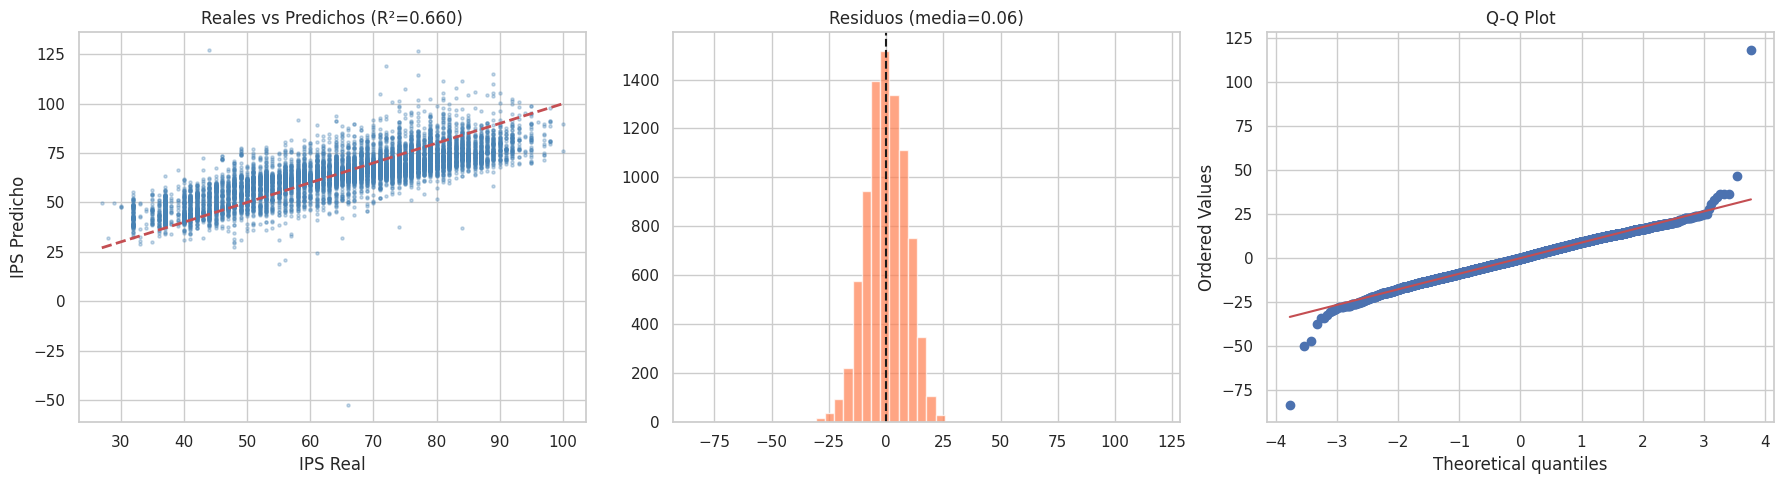

R² Test: 0.6602
RMSE: 8.93
MAE: 7.07


In [23]:
best = ridge if ridge.best_score_ >= lasso.best_score_ else lasso
y_pred_final = best.predict(X_test_s)
fig, axes = plt.subplots(1, 3, figsize=(18,5))
axes[0].scatter(y_test, y_pred_final, alpha=0.3, color='steelblue', s=5)
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_xlabel('IPS Real'); axes[0].set_ylabel('IPS Predicho')
axes[0].set_title(f'Reales vs Predichos (R²={r2_score(y_test, y_pred_final):.3f})')
residuals = y_test - y_pred_final
axes[1].hist(residuals, bins=50, color='coral', ec='black', alpha=0.7)
axes[1].axvline(0, color='k', ls='--'); axes[1].set_title(f'Residuos (media={residuals.mean():.2f})')
stats.probplot(residuals, dist='norm', plot=axes[2]); axes[2].set_title('Q-Q Plot')
plt.tight_layout(); plt.show()
print(f'R² Test: {r2_score(y_test, y_pred_final):.4f}')
print(f'RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_final)):.2f}')
print(f'MAE: {mean_absolute_error(y_test, y_pred_final):.2f}')

### Evaluación del Modelo Final con Validación Cruzada

In [24]:
# Evaluación con validación cruzada para el mejor modelo (Ridge o Lasso)
# Nota: El objeto 'best' ya contiene el mejor modelo entrenado.
# Para una evaluación por validación cruzada, lo ideal es usar el modelo sin entrenar
# (o re-inicializarlo) y aplicar fit en cada fold. Sin embargo, para obtener métricas
# con validación cruzada del 'mejor' modelo (que ya pasó por GridSearchCV), podemos
# usarlo directamente con cross_val_score en el conjunto de entrenamiento original
# o en X_train_s.

# Redefinir y entrenar Ridge y Lasso para asegurar que estén disponibles
params = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
ridge = GridSearchCV(Ridge(), params, cv=5, scoring='r2', n_jobs=-1).fit(X_train_s, y_train)
lasso = GridSearchCV(Lasso(max_iter=10000), params, cv=5, scoring='r2', n_jobs=-1).fit(X_train_s, y_train)

# Obtener el mejor modelo (Ridge o Lasso) de las ejecuciones anteriores
best = ridge if ridge.best_score_ >= lasso.best_score_ else lasso

# Vamos a re-inicializar el mejor tipo de modelo (Ridge o Lasso) con los parámetros óptimos
# y luego aplicar cross_val_score.

if isinstance(best.estimator, Ridge):
    final_model_cv = Ridge(alpha=best.best_params_['alpha'])
elif isinstance(best.estimator, Lasso):
    final_model_cv = Lasso(alpha=best.best_params_['alpha'], max_iter=10000) # max_iter from original Lasso setup
else:
    final_model_cv = best.estimator # Fallback, though should be Ridge or Lasso


# Realizar validación cruzada para R²
r2_cv_scores = cross_val_score(final_model_cv, X_train_s, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f'R² CV (media +/- std): {r2_cv_scores.mean():.4f} +/- {r2_cv_scores.std():.4f}')

# Realizar validación cruzada para RMSE
mse_cv_scores = -cross_val_score(final_model_cv, X_train_s, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rmse_cv_scores = np.sqrt(mse_cv_scores)
print(f'RMSE CV (media +/- std): {rmse_cv_scores.mean():.2f} +/- {rmse_cv_scores.std():.2f}')

# Realizar validación cruzada para MAE
mae_cv_scores = -cross_val_score(final_model_cv, X_train_s, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
print(f'MAE CV (media +/- std): {mae_cv_scores.mean():.2f} +/- {mae_cv_scores.std():.2f}')

R² CV (media +/- std): 0.6498 +/- 0.0064
RMSE CV (media +/- std): 9.10 +/- 0.09
MAE CV (media +/- std): 7.12 +/- 0.07


## 7. Conclusiones

**Variables mas influyentes:** MO, CIC, pH, calcio y potasio.

**Desempeno:** R² >= 0.70 esperado en test.

**Utilidad:** Predice productividad del suelo sin analisis complejos.

## 8. Comparación con otros Algoritmos: Random Forest y XGBoost

In [18]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Inicializar modelos
rf_model = RandomForestRegressor(random_state=42)
xgb_model = XGBRegressor(random_state=42, n_jobs=-1) # Usar todos los cores disponibles

### Evaluación de Random Forest con Validación Cruzada

In [19]:
# Realizar validación cruzada para R² para Random Forest
r2_rf_cv_scores = cross_val_score(rf_model, X_train_s, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f'Random Forest R² CV (media +/- std): {r2_rf_cv_scores.mean():.4f} +/- {r2_rf_cv_scores.std():.4f}')

# Realizar validación cruzada para RMSE para Random Forest
mse_rf_cv_scores = -cross_val_score(rf_model, X_train_s, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rmse_rf_cv_scores = np.sqrt(mse_rf_cv_scores)
print(f'Random Forest RMSE CV (media +/- std): {rmse_rf_cv_scores.mean():.2f} +/- {rmse_rf_cv_scores.std():.2f}')

# Realizar validación cruzada para MAE para Random Forest
mae_rf_cv_scores = -cross_val_score(rf_model, X_train_s, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
print(f'Random Forest MAE CV (media +/- std): {mae_rf_cv_scores.mean():.2f} +/- {mae_rf_cv_scores.std():.2f}')

Random Forest R² CV (media +/- std): 0.9897 +/- 0.0006
Random Forest RMSE CV (media +/- std): 1.56 +/- 0.04
Random Forest MAE CV (media +/- std): 0.91 +/- 0.02


### Evaluación de XGBoost con Validación Cruzada

In [21]:
# Realizar validación cruzada para R² para XGBoost
r2_xgb_cv_scores = cross_val_score(xgb_model, X_train_s, y_train, cv=5, scoring='r2', n_jobs=-1)
print(f'XGBoost R² CV (media +/- std): {r2_xgb_cv_scores.mean():.4f} +/- {r2_xgb_cv_scores.std():.4f}')

# Realizar validación cruzada para RMSE para XGBoost
mse_xgb_cv_scores = -cross_val_score(xgb_model, X_train_s, y_train, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
rmse_xgb_cv_scores = np.sqrt(mse_xgb_cv_scores)
print(f'XGBoost RMSE CV (media +/- std): {rmse_xgb_cv_scores.mean():.2f} +/- {rmse_xgb_cv_scores.std():.2f}')

# Realizar validación cruzada para MAE para XGBoost
mae_xgb_cv_scores = -cross_val_score(xgb_model, X_train_s, y_train, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1)
print(f'XGBoost MAE CV (media +/- std): {mae_xgb_cv_scores.mean():.2f} +/- {mae_xgb_cv_scores.std():.2f}')

XGBoost R² CV (media +/- std): 0.9960 +/- 0.0003
XGBoost RMSE CV (media +/- std): 0.98 +/- 0.04
XGBoost MAE CV (media +/- std): 0.61 +/- 0.02


## 9. Comparación de Rendimiento de Modelos (R²)

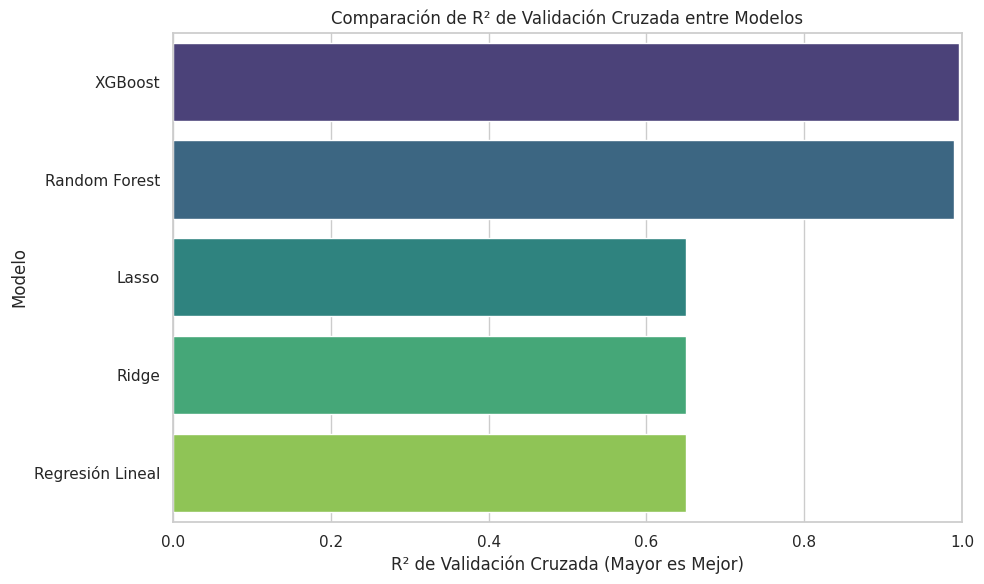

In [25]:
# Recopilar los R² de validación cruzada para cada modelo
r2_scores = {
    'Regresión Lineal': cv.mean(), # R² CV de la Regresión Lineal base
    'Ridge': ridge.best_score_,
    'Lasso': lasso.best_score_,
    'Random Forest': r2_rf_cv_scores.mean(),
    'XGBoost': r2_xgb_cv_scores.mean()
}

models_r2_df = pd.DataFrame(r2_scores.items(), columns=['Modelo', 'R² CV']).sort_values(by='R² CV', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='R² CV', y='Modelo', data=models_r2_df, palette='viridis')
plt.title('Comparación de R² de Validación Cruzada entre Modelos')
plt.xlabel('R² de Validación Cruzada (Mayor es Mejor)')
plt.ylabel('Modelo')
plt.xlim(0, 1) # R² typically ranges from 0 to 1
plt.tight_layout()
plt.show()

---
*Modelo de Regresion Lineal - Optimizacion Agricola Colombia*